# 1. Exploración de Datos — Predicting Stellar Class

Problema de **clasificación multiclase**: predecir la clase de un objeto astronómico
(`GALAXY` / `QSO` / `STAR`) a partir de mediciones fotométricas y espectroscópicas (estilo SDSS).

Se realiza exploración tabular y visual del dataset de entrenamiento para entender la distribución
de las variables, su relación con el target y detectar posibles issues de calidad.

**Dataset:** Playground Series S6E6

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

# Coordenadas en el cielo
coordenadas = ["alpha", "delta"]
# Magnitudes fotométricas (filtros SDSS) + redshift
fotometricas = ["u", "g", "r", "i", "z"]
espectro     = ["redshift"]
numericas    = coordenadas + fotometricas + espectro

categoricas = ["spectral_type", "galaxy_population"]

TARGET      = "class"
CLASS_ORDER = ["GALAXY", "QSO", "STAR"]
PALETTE     = {"GALAXY": "steelblue", "QSO": "tomato", "STAR": "goldenrod"}

print(f"Train: {train.shape[0]:,} filas x {train.shape[1]} columnas")
print(f"Test:  {test.shape[0]:,} filas x {test.shape[1]} columnas")
print(f"Variables numericas:   {len(numericas)} -> {numericas}")
print(f"Variables categoricas: {len(categoricas)} -> {categoricas}")

Train: 577,347 filas x 12 columnas
Test:  247,435 filas x 11 columnas
Variables numericas:   8 -> ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
Variables categoricas: 2 -> ['spectral_type', 'galaxy_population']


## 2. Visión General del Dataset

In [3]:
train.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


In [5]:
train[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
alpha,577347.0,181.616673,96.242941,0.011684,132.161499,188.681465,231.829693,359.999810
delta,577347.0,21.834654,18.933570,-17.966988,2.474097,21.484412,36.988310,79.158322
u,577347.0,22.441926,2.018135,-0.139225,20.977090,22.570222,23.869103,28.253263
g,577347.0,21.007273,1.795426,13.535483,19.865005,21.467820,22.292715,27.620208
r,577347.0,19.962811,1.648964,12.579407,18.820671,20.431153,21.164096,25.254499
i,577347.0,19.378911,1.580059,11.962781,18.306820,19.631642,20.608191,27.910853
z,577347.0,19.041136,1.584365,11.682803,17.973192,19.188598,20.162111,26.826867
redshift,577347.0,0.723135,0.810070,-0.009970,0.181052,0.497525,0.881390,7.010780


In [6]:
print("Valores nulos por columna:")
print(train.isnull().sum())
print(f"\nFilas duplicadas (excluyendo id): {train.drop(columns='id').duplicated().sum():,}")
print("\nCardinalidad de categoricas:")
for c in categoricas:
    print(f"  {c:18s}: {train[c].nunique()} -> {sorted(train[c].unique())}")

Valores nulos por columna:
id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64



Filas duplicadas (excluyendo id): 0

Cardinalidad de categoricas:
  spectral_type     : 4 -> ['A/F', 'G/K', 'M', 'O/B']


  galaxy_population : 2 -> ['Blue_Cloud', 'Red_Sequence']


## 3. Distribución del Target

DISTRIBUCION DEL TARGET
  GALAXY  :  377,480  (65.38%)
  QSO     :  117,143  (20.29%)
  STAR    :   82,724  (14.33%)
  Ratio mayoritaria/minoritaria: 4.56x


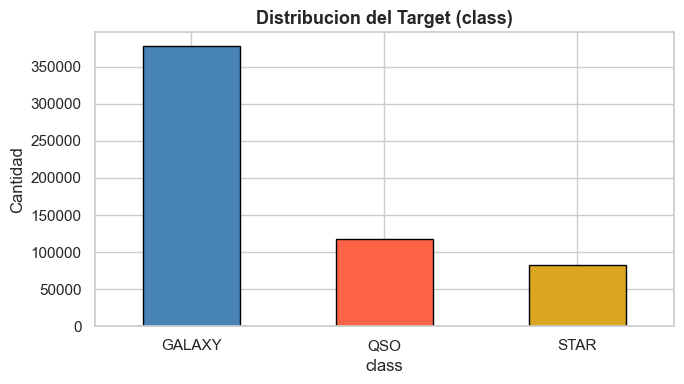

In [7]:
counts = train[TARGET].value_counts().reindex(CLASS_ORDER)
props  = train[TARGET].value_counts(normalize=True).reindex(CLASS_ORDER)

print(f"{'='*45}")
print("DISTRIBUCION DEL TARGET")
print(f"{'='*45}")
for cls in CLASS_ORDER:
    print(f"  {cls:8s}: {counts[cls]:>8,}  ({props[cls]*100:.2f}%)")
print(f"{'='*45}")
print(f"  Ratio mayoritaria/minoritaria: {counts.max()/counts.min():.2f}x")

fig, ax = plt.subplots(figsize=(7, 4))
counts.plot.bar(ax=ax, color=[PALETTE[c] for c in CLASS_ORDER], edgecolor="black")
ax.set_title("Distribucion del Target (class)", fontsize=13, fontweight="bold")
ax.set_ylabel("Cantidad")
ax.set_xlabel("class")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Variables Numéricas — Distribuciones

`redshift` está fuertemente sesgada a derecha (objetos cercanos con z≈0 y cuásares con z alto),
por eso se grafica también en escala logarítmica.

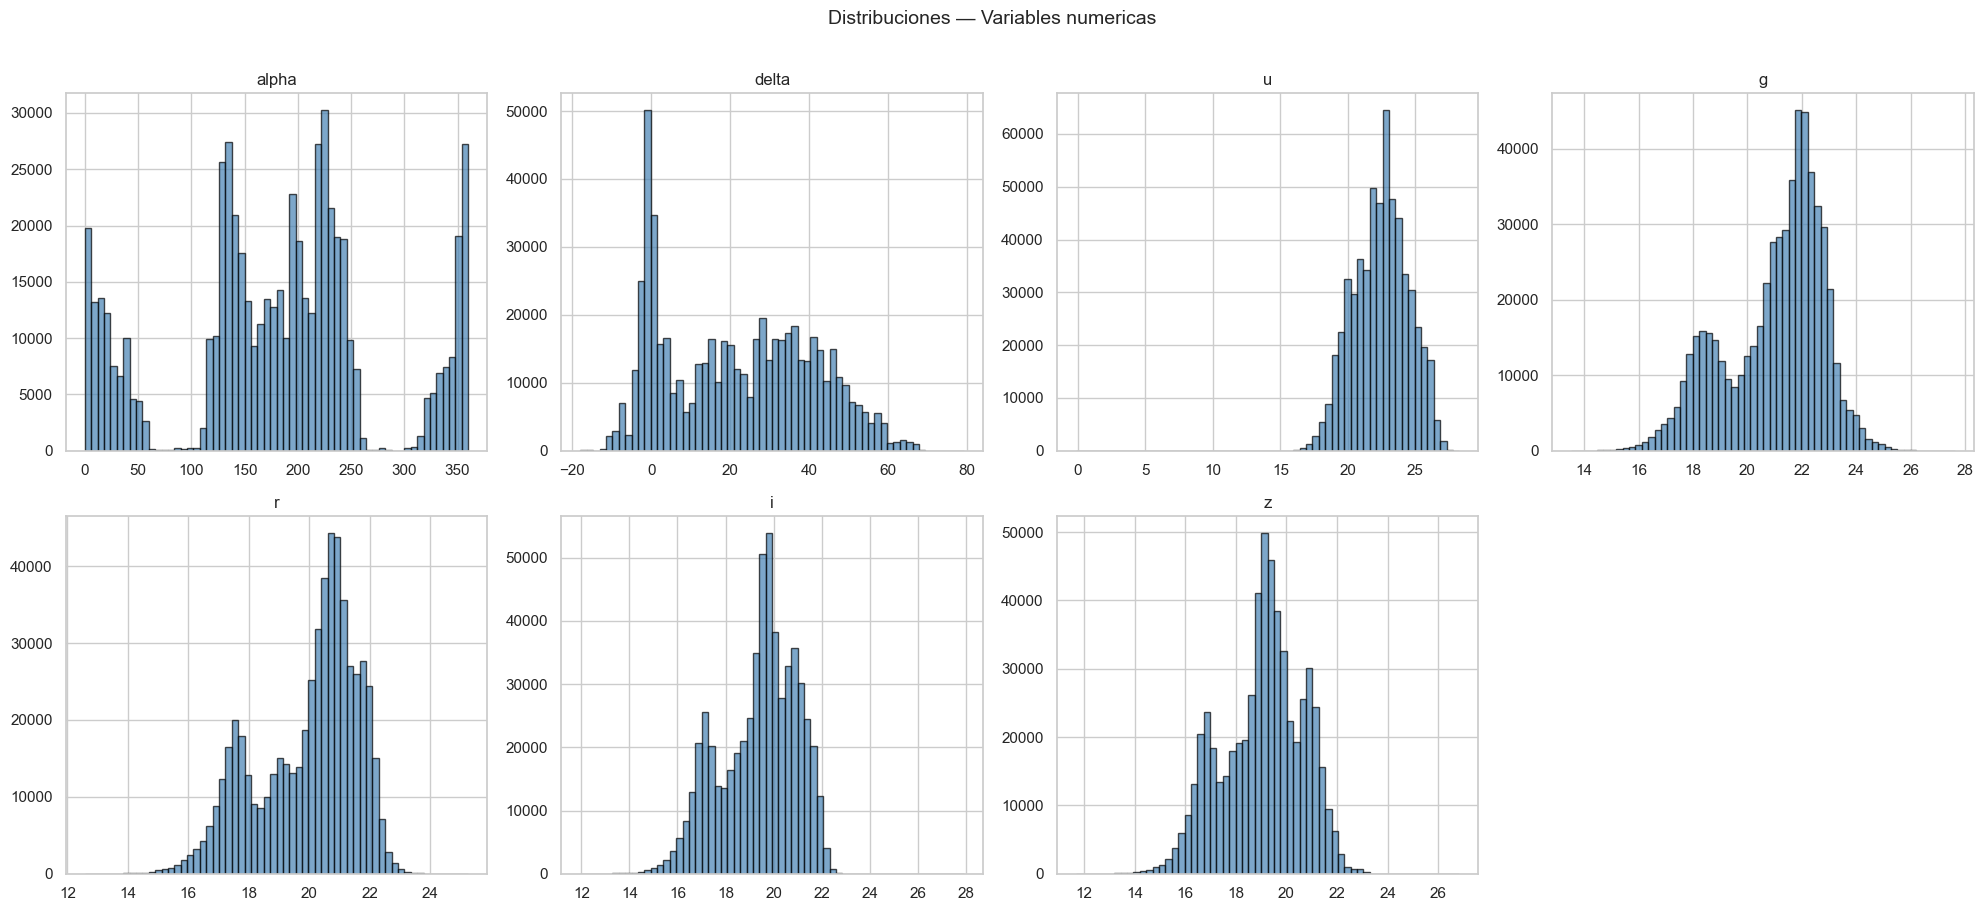

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.flat, numericas):
    train[col].hist(bins=60, ax=ax, color="steelblue", edgecolor="black", alpha=0.7)
    ax.set_title(col)
axes.flat[-1].set_visible(False)
plt.suptitle("Distribuciones — Variables numericas", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

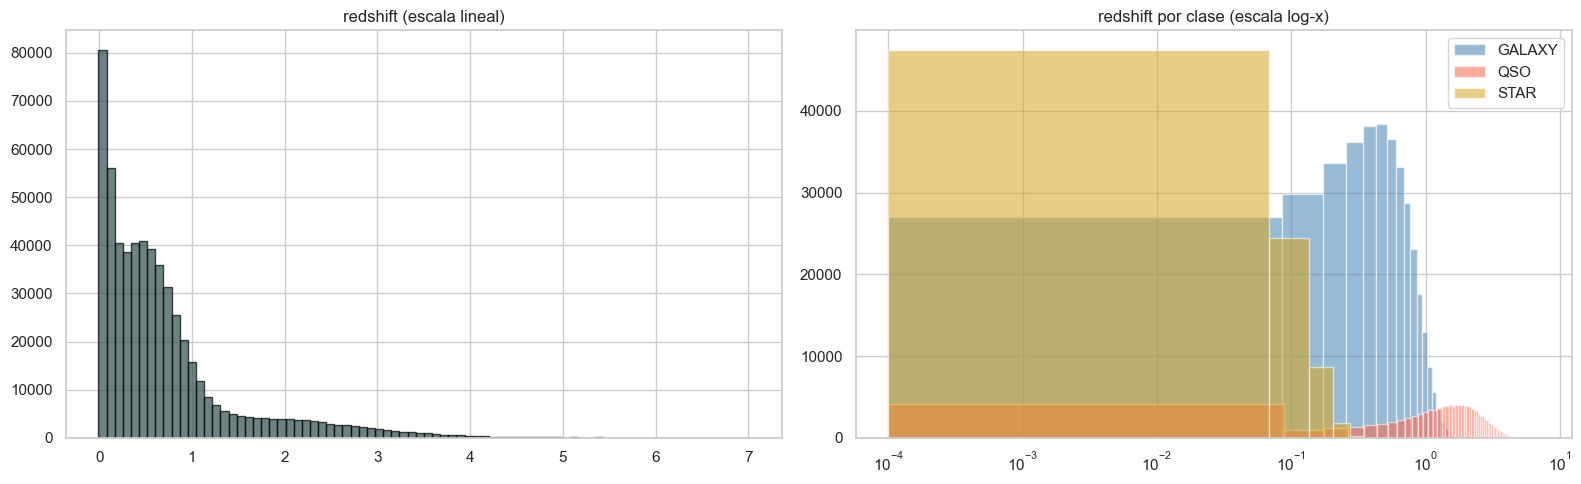

In [9]:
# redshift: vista en escala log para apreciar su estructura multimodal por clase
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(train["redshift"], bins=80, color="darkslategray", edgecolor="black", alpha=0.7)
axes[0].set_title("redshift (escala lineal)")
for cls in CLASS_ORDER:
    sub = train.loc[train[TARGET] == cls, "redshift"]
    axes[1].hist(sub.clip(lower=1e-4), bins=80, alpha=0.55, label=cls, color=PALETTE[cls])
axes[1].set_xscale("log")
axes[1].set_title("redshift por clase (escala log-x)")
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Variables Numéricas vs Target

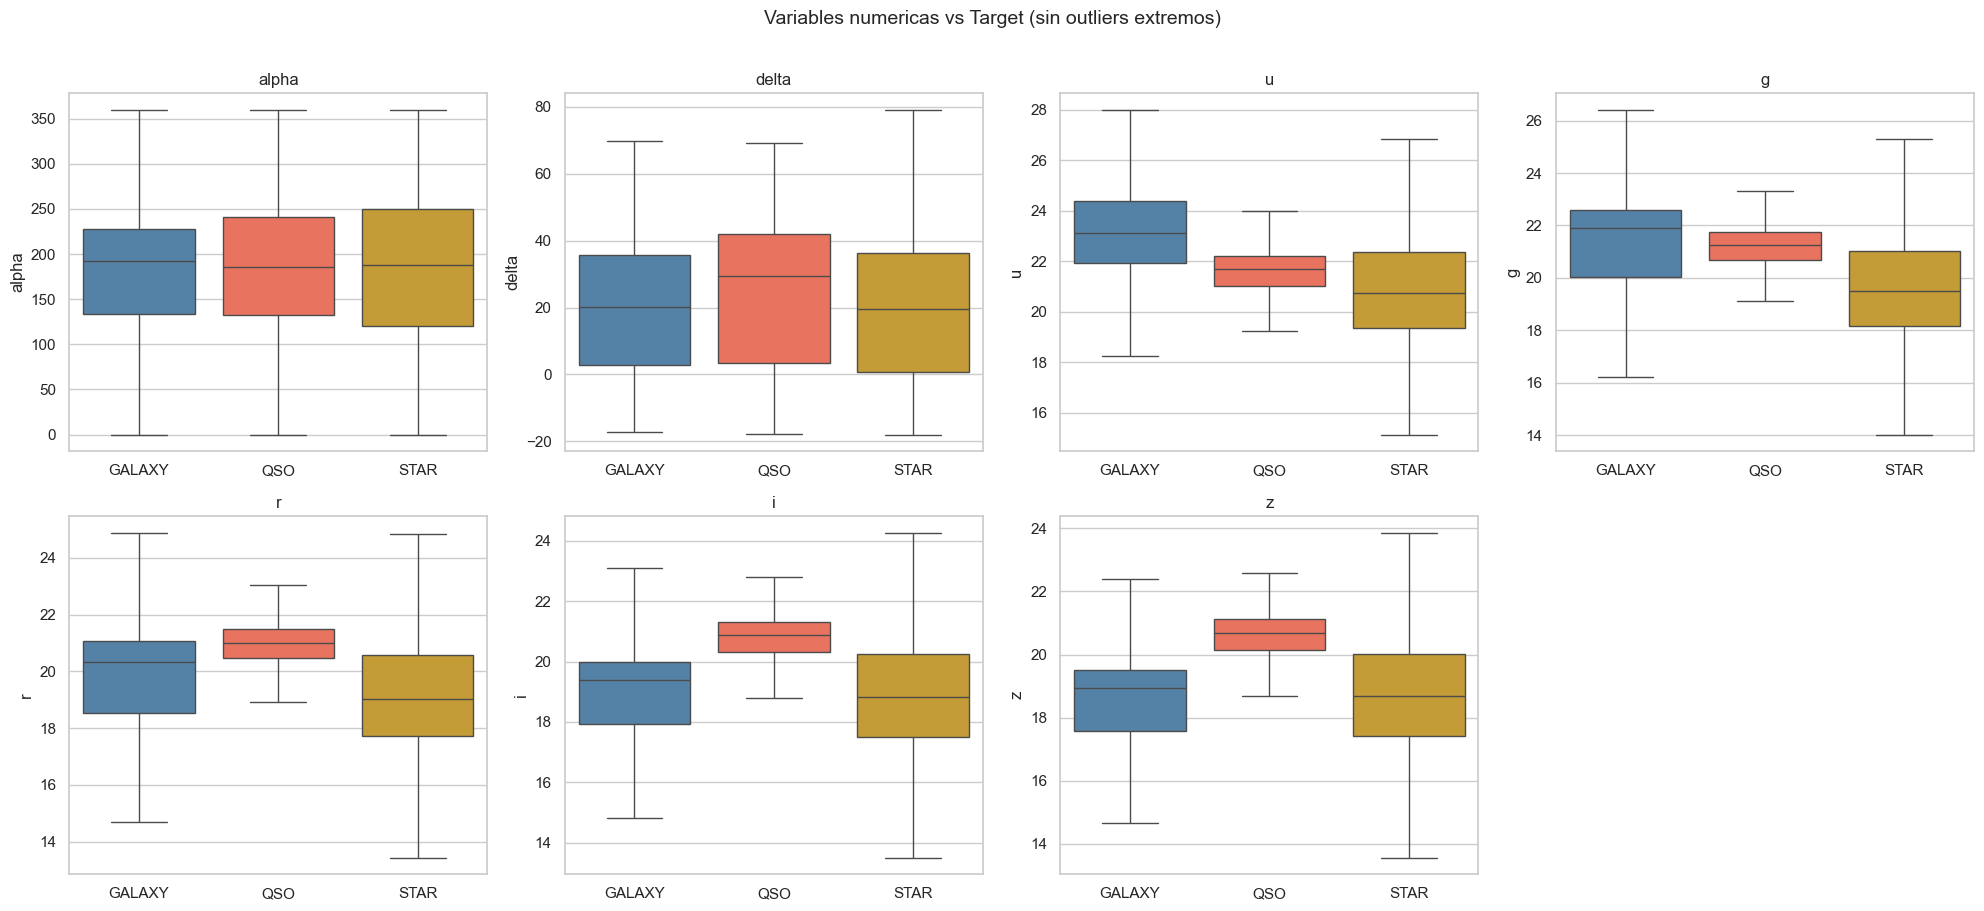

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.flat, numericas):
    sns.boxplot(data=train, x=TARGET, y=col, order=CLASS_ORDER,
                palette=PALETTE, showfliers=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
axes.flat[-1].set_visible(False)
plt.suptitle("Variables numericas vs Target (sin outliers extremos)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Índices de Color (feature engineering astronómico)

En clasificación estelar los **índices de color** (diferencias entre magnitudes de filtros adyacentes)
suelen ser más informativos que las magnitudes crudas, porque capturan la forma del espectro
independizándose del brillo absoluto del objeto.

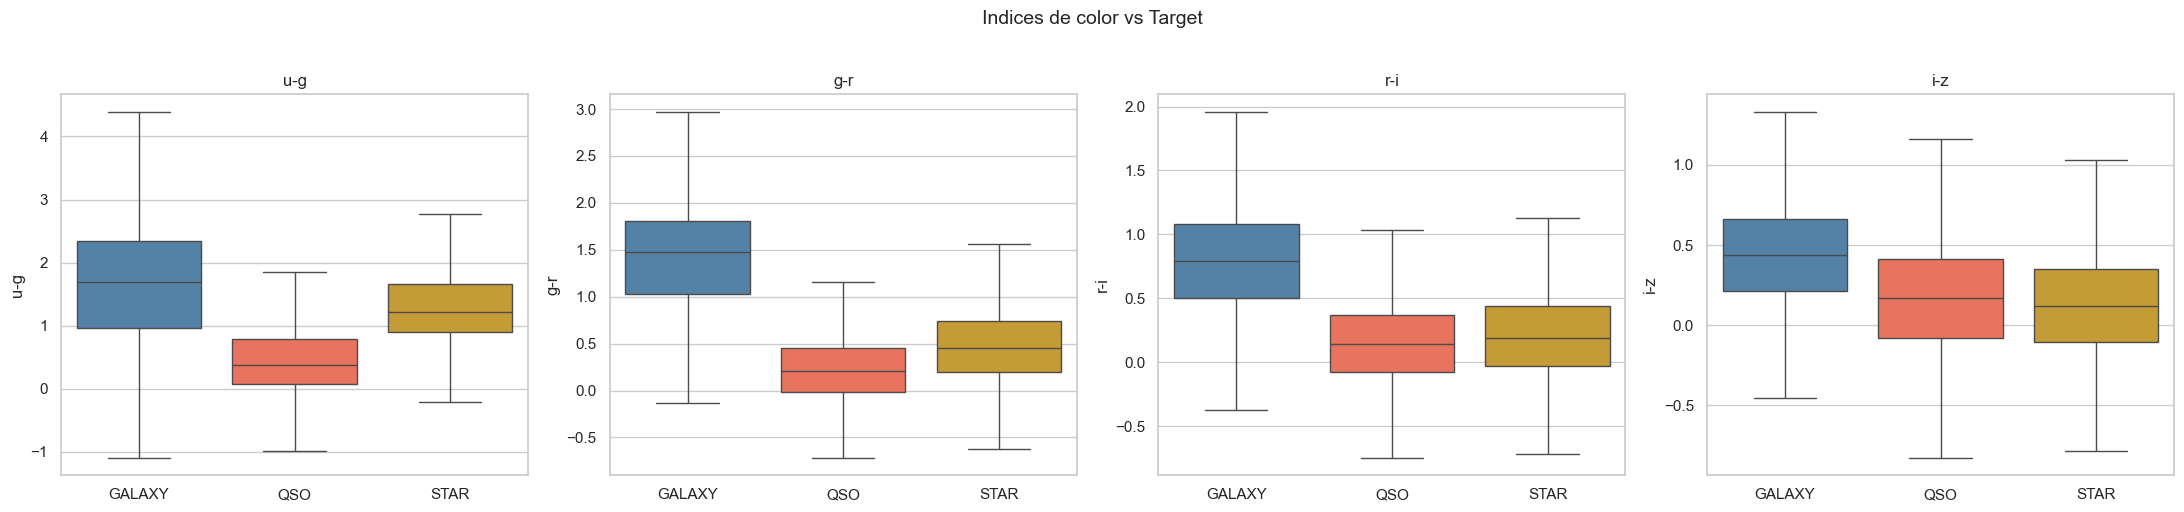

In [11]:
colores = {"u-g": ("u", "g"), "g-r": ("g", "r"), "r-i": ("r", "i"), "i-z": ("i", "z")}
for nombre, (a, b) in colores.items():
    train[nombre] = train[a] - train[b]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, col in zip(axes.flat, colores):
    sns.boxplot(data=train, x=TARGET, y=col, order=CLASS_ORDER,
                palette=PALETTE, showfliers=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Indices de color vs Target", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Variables Categóricas vs Target

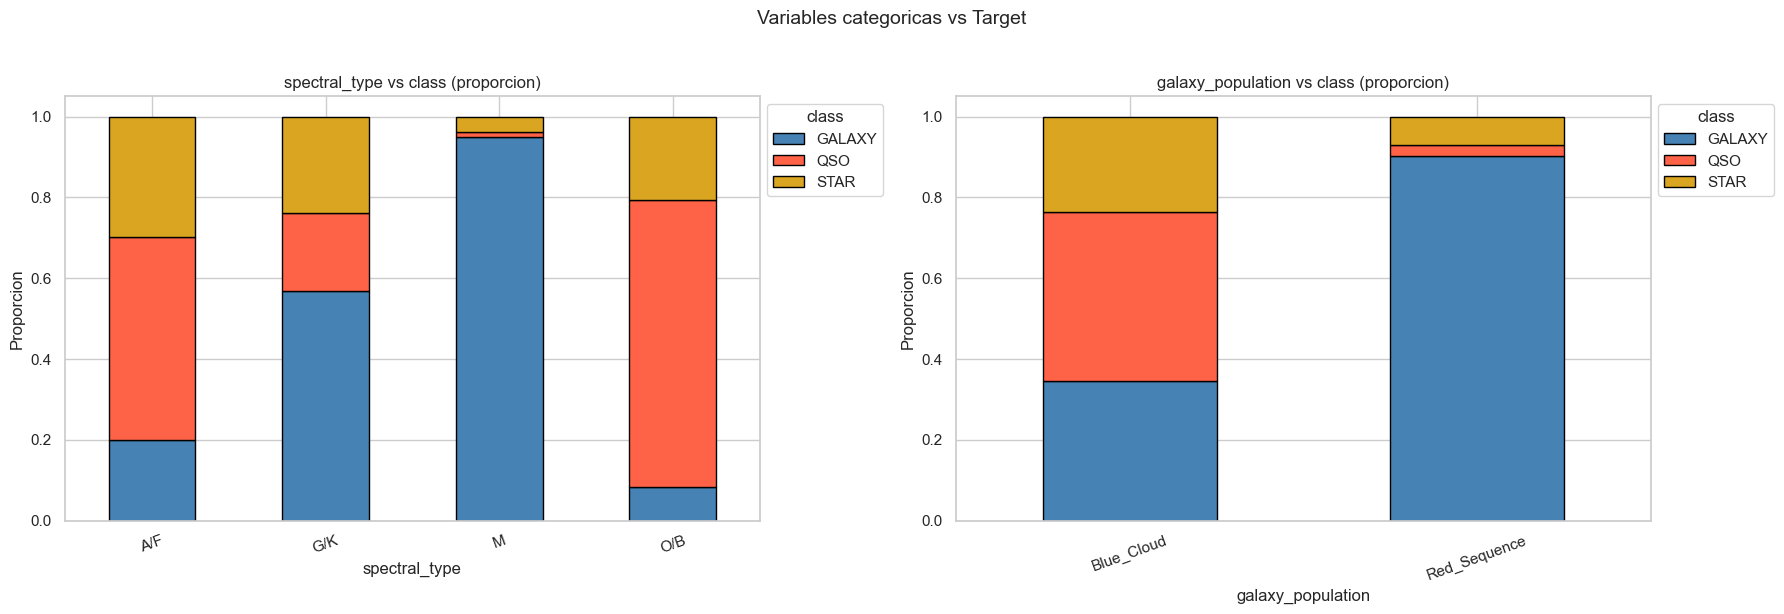

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, col in zip(axes.flat, categoricas):
    props_c = (
        train.groupby(col)[TARGET]
             .value_counts(normalize=True)
             .unstack(fill_value=0)
             .reindex(columns=CLASS_ORDER, fill_value=0)
    )
    props_c.plot.bar(stacked=True, ax=ax,
                     color=[PALETTE[c] for c in CLASS_ORDER], edgecolor="black")
    ax.set_title(f"{col} vs class (proporcion)")
    ax.set_ylabel("Proporcion")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="class", bbox_to_anchor=(1.0, 1.0))
plt.suptitle("Variables categoricas vs Target", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Cobertura del Cielo (alpha vs delta)

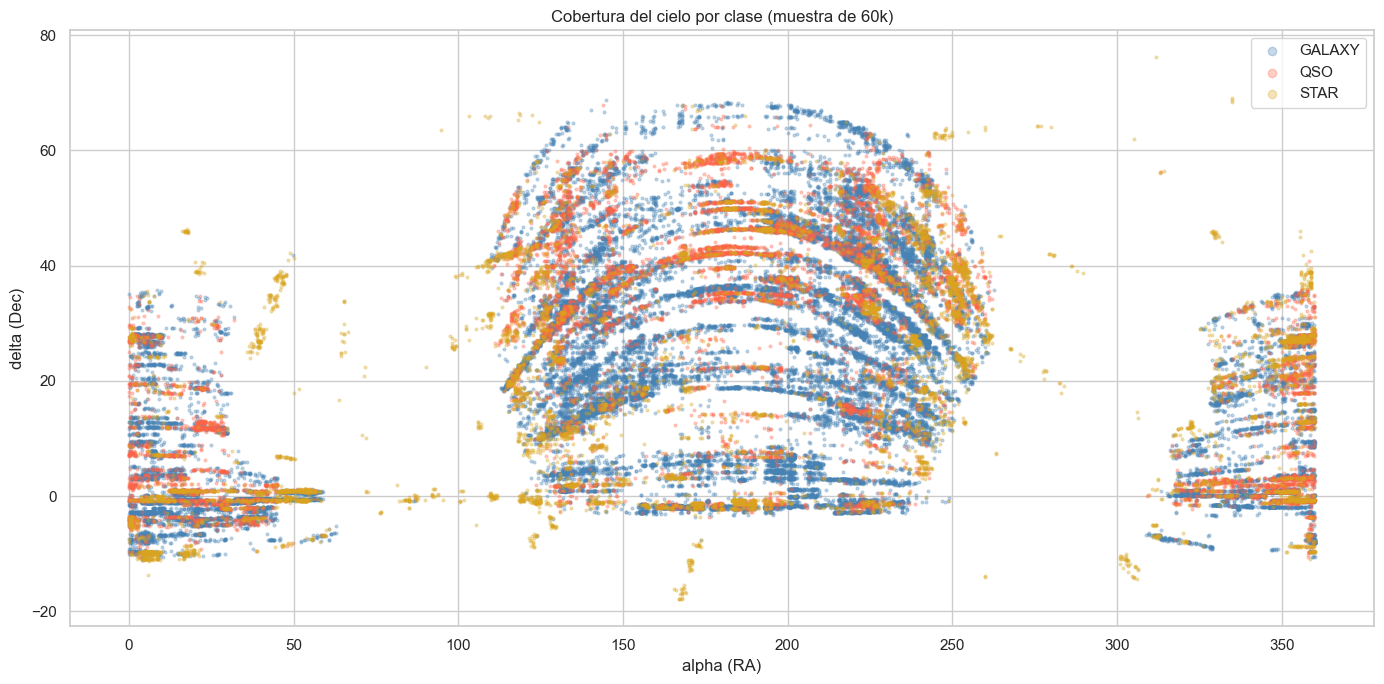

In [13]:
muestra = train.sample(n=min(60000, len(train)), random_state=42)
fig, ax = plt.subplots(figsize=(14, 7))
for cls in CLASS_ORDER:
    sub = muestra[muestra[TARGET] == cls]
    ax.scatter(sub["alpha"], sub["delta"], s=4, alpha=0.3, label=cls, color=PALETTE[cls])
ax.set_xlabel("alpha (RA)")
ax.set_ylabel("delta (Dec)")
ax.set_title("Cobertura del cielo por clase (muestra de 60k)")
leg = ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

## 9. Correlaciones

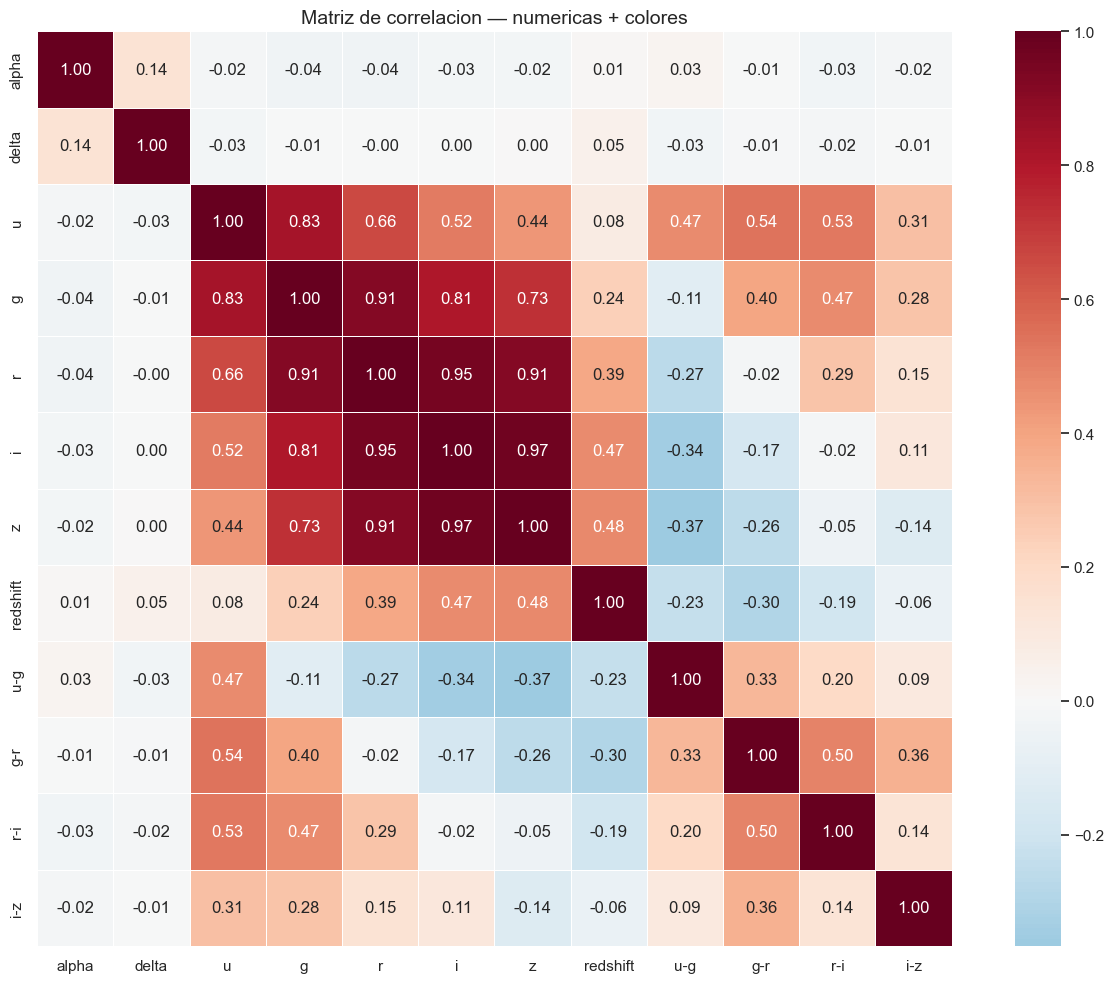

In [14]:
cols_corr = numericas + list(colores.keys())
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(train[cols_corr].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlacion — numericas + colores", fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# Correlacion de cada numerica/color con el target codificado (orden GALAXY<QSO<STAR es arbitrario,
# se usa solo como referencia rapida; el analisis monotono fino esta en el notebook 2).
df_corr = train[cols_corr].copy()
df_corr["target_enc"] = train[TARGET].map({c: i for i, c in enumerate(CLASS_ORDER)})
corr_t = df_corr.corr()["target_enc"].drop("target_enc").abs().sort_values(ascending=False)
print("Correlacion (absoluta) con target codificado:")
print(corr_t.round(4))

Correlacion (absoluta) con target codificado:
g-r         0.5834
r-i         0.5078
u           0.3857
i-z         0.3327
g           0.2850
u-g         0.2335
z           0.1905
i           0.1076
redshift    0.0778
r           0.0498
alpha       0.0336
delta       0.0174
Name: target_enc, dtype: float64


## 10. Conclusiones

- **Dataset limpio**: 577.347 filas, sin nulos ni duplicados; 8 numéricas + 2 categóricas + target.
- **Target desbalanceado**: GALAXY ~65%, QSO ~20%, STAR ~14%. Conviene estratificar en CV y considerar
  métricas/pesos sensibles al desbalance.
- **`redshift` es la variable más discriminativa**: las STAR se concentran en z≈0, las GALAXY en z bajo
  y los QSO en z alto. Es el separador natural del problema.
- **Índices de color** (`u-g`, `g-r`, `r-i`, `i-z`) separan bien las clases y son candidatos fuertes
  como features derivadas, mejor que las magnitudes crudas (muy correlacionadas entre sí).
- **Categóricas informativas**: `spectral_type` y `galaxy_population` muestran composiciones de clase
  muy distintas según el nivel.
- **`alpha`/`delta`** aportan poca señal directa de clase (cobertura del cielo similar entre clases).
- El detalle de **relaciones monótonas** variable→clase se profundiza en `2_bivariado_monotonia.ipynb`.